# Band Ablation Visualizer

Shows what the detectors actually *see* under each ablation condition.

**What band ablation does:**
1. Take a normalized 256×256 image
2. Compute 2D FFT per channel, shift DC to center
3. Zero out all coefficients in a radial band
4. Inverse FFT → clip to [0, 255]

**Band definitions** (r_max = 128 for 256×256):
- `low`:  r < 0.2 · r_max  (DC + coarse structure, 0–25px from center)
- `mid`:  0.2 ≤ r < 0.6 · r_max  (mid-range texture, 25–76px)
- `high`: r ≥ 0.6 · r_max  (fine detail + edges, 76–128px)

In [15]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LogNorm
from pathlib import Path
from PIL import Image

from scripts.band_ablation import make_band_mask, ablate_image

In [16]:
# ── Dataset selector ──────────────────────────────────────────────────────────
# Change DATASET to switch between datasets. Everything below auto-adjusts.
#
#   'genimage'  — ImageNet-nature (real) vs ADM-generated (fake) ← best quality
#   'defactify' — news article images vs multiple generators
#   'cifake'    — CIFAR-10 upsampled 32→256 (blurry, toy-scale)
# ─────────────────────────────────────────────────────────────────────────────
DATASET = 'genimage'

NORM_ROOTS = {
    'genimage':  Path('/root/normalized/genimage'),
    'defactify': Path('/root/normalized/defactify/test'),
    'cifake':    Path('/root/normalized/cifake/test'),
}
ABLAT_ROOTS = {
    'genimage':  Path('/root/ablated/genimage'),
    'defactify': Path('/root/ablated/defactify'),
    'cifake':    Path('/root/ablated/cifake'),
}

NORM_ROOT  = NORM_ROOTS[DATASET]
ABLAT_ROOT = ABLAT_ROOTS[DATASET]

real_files = sorted((NORM_ROOT / 'real').glob('*.png'))
fake_files = sorted((NORM_ROOT / 'fake').glob('*.png'))

print(f"Dataset : {DATASET}")
print(f"Real    : {len(real_files)} images")
print(f"Fake    : {len(fake_files)} images")

Dataset : genimage
Real    : 0 images
Fake    : 0 images


## 1 — Band masks: what gets zeroed out

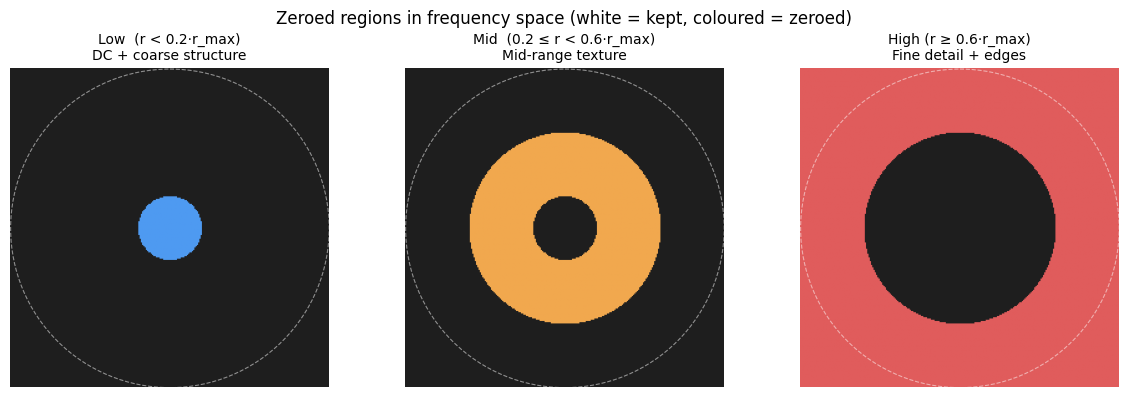

In [17]:
H, W = 256, 256
bands = ['low', 'mid', 'high']
colors = {'low': '#4e9af1', 'mid': '#f1a84e', 'high': '#e05c5c'}
labels = {
    'low':  'Low  (r < 0.2·r_max)\nDC + coarse structure',
    'mid':  'Mid  (0.2 ≤ r < 0.6·r_max)\nMid-range texture',
    'high': 'High (r ≥ 0.6·r_max)\nFine detail + edges',
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, band in zip(axes, bands):
    mask = make_band_mask(H, W, band)
    display = np.zeros((H, W, 3))
    rgb = np.array(plt.cm.colors.to_rgb(colors[band]))
    display[mask] = rgb
    display[~mask] = [0.12, 0.12, 0.12]
    ax.imshow(display, origin='upper')
    ax.set_title(labels[band], fontsize=10)
    ax.axis('off')
    # Draw r_max circle for reference
    r_max = min(H // 2, W // 2)
    circle = plt.Circle((W//2, H//2), r_max, color='white', fill=False, lw=0.8, ls='--', alpha=0.5)
    ax.add_patch(circle)

fig.suptitle('Zeroed regions in frequency space (white = kept, coloured = zeroed)', fontsize=12)
plt.tight_layout()
plt.savefig('../figures/band_masks.png', dpi=150, bbox_inches='tight')
plt.show()

## 2 — Original vs ablated: real image

In [18]:
def show_ablation_row(img_path, title_prefix='', idx=0):
    """Show original + 3 ablated versions + removed-content maps for one image."""
    orig = Image.open(img_path).convert('RGB')
    orig_arr = np.array(orig)

    ablated = {b: ablate_image(orig, b) for b in bands}
    removed = {b: np.clip(orig_arr.astype(int) - np.array(ablated[b]).astype(int) + 128, 0, 255).astype(np.uint8)
               for b in bands}

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(f'[{DATASET}]  {title_prefix}  —  {Path(img_path).name}', fontsize=12)

    axes[0, 0].imshow(orig_arr)
    axes[0, 0].set_title('Original (normalized)', fontweight='bold')
    for i, band in enumerate(bands):
        axes[0, i+1].imshow(np.array(ablated[band]))
        axes[0, i+1].set_title(f'{band.capitalize()} removed', color=colors[band], fontweight='bold')

    gray = np.array(orig.convert('L')).astype(np.float32)
    spectrum = np.abs(np.fft.fftshift(np.fft.fft2(gray)))
    axes[1, 0].imshow(spectrum, norm=LogNorm(vmin=1), cmap='inferno')
    axes[1, 0].set_title('Log power spectrum', fontsize=9)

    for i, band in enumerate(bands):
        axes[1, i+1].imshow(removed[band])
        axes[1, i+1].set_title(f'Removed content ({band})\n(orig − ablated + 128)', fontsize=9)

    for ax in axes.flat:
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(f'../figures/ablation_viz_{DATASET}_{title_prefix.lower().replace(" ","_")}_{idx}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

show_ablation_row(real_files[0], title_prefix='REAL', idx=0)

IndexError: list index out of range

## 3 — Original vs ablated: fake image

In [ ]:
show_ablation_row(fake_files[0], title_prefix='FAKE', idx=0)

## 4 — Side-by-side: real vs fake under each condition

The key visual question: does removing a band make real and fake images *look* the same?  
If a detector collapses, it should be because the visual difference disappears.

In [ ]:
def compare_real_fake(real_path, fake_path):
    """Grid: rows = conditions (original, low, mid, high), cols = real | fake."""
    row_labels = ['Original', 'Low removed', 'Mid removed', 'High removed']

    real_imgs = [Image.open(real_path).convert('RGB')]
    fake_imgs = [Image.open(fake_path).convert('RGB')]
    for b in bands:
        real_imgs.append(ablate_image(real_imgs[0], b))
        fake_imgs.append(ablate_image(fake_imgs[0], b))

    fig, axes = plt.subplots(4, 2, figsize=(6, 12))
    fig.suptitle(f'[{DATASET}]  Real (left) vs Fake (right)', fontsize=11)

    for row, (r_img, f_img, label) in enumerate(zip(real_imgs, fake_imgs, row_labels)):
        axes[row, 0].imshow(np.array(r_img))
        axes[row, 1].imshow(np.array(f_img))
        axes[row, 0].set_ylabel(label, fontsize=10, rotation=90, labelpad=4)
        if row == 0:
            axes[row, 0].set_title('Real', fontweight='bold')
            axes[row, 1].set_title('Fake', fontweight='bold')

    for ax in axes.flat:
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.savefig(f'../figures/ablation_real_vs_fake_{DATASET}.png', dpi=150, bbox_inches='tight')
    plt.show()

compare_real_fake(real_files[0], fake_files[0])

## 5 — Mean image per condition

Average over N real and N fake images to see if population-level differences persist under ablation.

In [ ]:
N = 64  # images to average

def mean_images(file_list, n=N):
    acc = {cond: np.zeros((256, 256, 3), dtype=np.float64)
           for cond in ['original'] + bands}
    for p in file_list[:n]:
        img = Image.open(p).convert('RGB')
        acc['original'] += np.array(img)
        for b in bands:
            acc[b] += np.array(ablate_image(img, b))
    return {k: (v / n).astype(np.uint8) for k, v in acc.items()}

print(f'Computing mean over {N} real images...')
real_means = mean_images(real_files)
print(f'Computing mean over {N} fake images...')
fake_means = mean_images(fake_files)

conditions = ['original'] + bands
labels_cond = ['Original', 'Low removed', 'Mid removed', 'High removed']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(f'[{DATASET}]  Mean image (N={N}) — top: real, bottom: fake', fontsize=12)

for col, (cond, label) in enumerate(zip(conditions, labels_cond)):
    axes[0, col].imshow(real_means[cond])
    axes[0, col].set_title(label, fontweight='bold')
    axes[1, col].imshow(fake_means[cond])
    axes[0, col].axis('off')
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Real', fontsize=11)
axes[1, 0].set_ylabel('Fake', fontsize=11)

plt.tight_layout()
plt.savefig(f'../figures/ablation_mean_images_{DATASET}.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 — Mean log-power spectrum: real vs fake per condition

The spectral signature before and after each ablation.  
This is the direct visual proof that the band was zeroed.

In [ ]:
def mean_spectrum(file_list, band=None, n=N):
    acc = np.zeros((256, 256), dtype=np.float64)
    for p in file_list[:n]:
        if band:
            img = ablate_image(Image.open(p).convert('RGB'), band).convert('L')
        else:
            img = Image.open(p).convert('L')
        arr = np.array(img).astype(np.float32)
        acc += np.abs(np.fft.fftshift(np.fft.fft2(arr)))
    return acc / n

print('Computing mean spectra (~30s for 64 images × 4 conditions × 2 classes)...')
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(f'[{DATASET}]  Mean log-power spectrum (N={N}) — top: real, bottom: fake', fontsize=12)

vmax = None

for col, (cond, label) in enumerate(zip(conditions, labels_cond)):
    b = None if cond == 'original' else cond
    r_spec = mean_spectrum(real_files, band=b)
    f_spec = mean_spectrum(fake_files, band=b)
    vmax = max(r_spec.max(), f_spec.max()) if vmax is None else vmax

    for row, spec in enumerate([r_spec, f_spec]):
        im = axes[row, col].imshow(spec, norm=LogNorm(vmin=1, vmax=vmax), cmap='inferno')
        axes[row, col].set_title(label if row == 0 else '', fontweight='bold')
        axes[row, col].axis('off')

axes[0, 0].set_ylabel('Real', fontsize=11)
axes[1, 0].set_ylabel('Fake', fontsize=11)
fig.colorbar(im, ax=axes[:, -1], shrink=0.8, label='Mean magnitude')

plt.tight_layout()
plt.savefig(f'../figures/ablation_mean_spectra_{DATASET}.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 — Browse individual images

Change `idx` and `split` to inspect any image.

In [ ]:
idx   = 5      # which image (0-indexed)
split = 'fake' # 'real' or 'fake'

file_list = fake_files if split == 'fake' else real_files
show_ablation_row(file_list[idx], title_prefix=split.upper(), idx=idx)